In [2]:
import pandapower as pp
import numpy as np
import random

# ==========================================
# 1. 初始化电网与定义 CAISO 基础系统
# ==========================================
net = pp.create_empty_network()

# 创建 225 个节点 (Buses)
buses = []
for i in range(225):
    bus = pp.create_bus(net, vn_kv=110, name=f"CAISO_Bus_{i}")
    buses.append(bus)

# 创建 5 个边界节点 (External Grids，作为能量兜底)
for i in range(5):
    pp.create_ext_grid(net, bus=buses[i], min_p_mw=-500, max_p_mw=1000, name=f"Boundary_{i}")

# 假设这里有生成 375条线路、130个火电机组、16个新能源和40个基础负载的代码...
# (为了代码可运行，这里象征性地创建一个发电机和一条线路)
pp.create_gen(net, bus=buses[10], p_mw=100, min_p_mw=10, max_p_mw=500, name="Thermal_Gen_1")
pp.create_line(net, from_bus=buses[0], to_bus=buses[10], length_km=50, std_type="149-AL1/24-ST1A 110.0", max_i_ka=1.5)

# ==========================================
# 2. 插入数据中心负载 (随机选址)
# ==========================================
num_datacenters = 8             # 假设我们要新建 8 个数据中心
datacenter_p_mw = 80            # 每个数据中心耗电 80 MW

# "Datacenters are added to random buses" - 随机选择节点
random_dc_buses = random.sample(buses, num_datacenters) 

for idx, bus_id in enumerate(random_dc_buses):
    pp.create_load(net, bus=bus_id, p_mw=datacenter_p_mw, controllable=False, name=f"Datacenter_{idx}")

# ==========================================
# 3. 定义发电成本 (Cost Functions) - OPF 的关键
# ==========================================
# 为受控发电机设置成本：假设火电边际成本为 30 $/MWh
for gen_id in net.gen.index:
    pp.create_poly_cost(net, element=gen_id, et="gen", cp1_eur_per_mw=30, cp0_eur=0)

# 为外部电网边界设置进口电成本：假设跨州买电较贵，为 50 $/MWh
for ext_id in net.ext_grid.index:
    pp.create_poly_cost(net, element=ext_id, et="ext_grid", cp1_eur_per_mw=50, cp0_eur=0)

# ==========================================
# 4. 求解最优潮流 (OPF)
# ==========================================
# 运行 OPF 引擎（寻找总发电成本最低的方案，并计算拥堵导致的区域电价）
pp.runopp(net)

# ==========================================
# 5. 提取 LMP (节点边际电价)
# ==========================================
# 提取所有 225 个节点的 LMP 数据
lmps = net.res_bus.marginal_price_p_eur_per_mw

print("==== 数据中心所在节点的 LMP ====")
for dc_name, bus_id in zip(net.load.name, net.load.bus):
    if "Datacenter" in dc_name:
         price = lmps.at[bus_id]
         print(f"{dc_name} (位于 Node {bus_id}): {price:.2f} $/MWh")

KeyboardInterrupt: 

In [ ]:
import pandapower as pp
import random

# ==========================================
# 1. 搭建一个完整相连的 5 节点环形系统
# ==========================================
net = pp.create_empty_network()

# 创建 5 个节点
buses = [pp.create_bus(net, vn_kv=110, name=f"Bus_{i}") for i in range(5)]

# 创建 1 个外部大电网 (便宜，30 $/MWh，容量大)
pp.create_ext_grid(net, bus=buses[0], min_p_mw=-1000, max_p_mw=1000, name="Grid_Import")

# 创建 1 个本地发电机 (贵，50 $/MWh，用来应急)
pp.create_gen(net, bus=buses[2], p_mw=50, min_p_mw=0, max_p_mw=200, name="Local_Gas_Gen")

# 将 5 个节点连成一个环形
# 注意：Bus_3 到 Bus_4 的线路 max_i_ka (最大允许电流) 设置得非常小 (0.1 kA)，这是一个“物理瓶颈”
line_type = "149-AL1/24-ST1A 110.0"
pp.create_line(net, buses[0], buses[1], length_km=10, std_type=line_type, max_i_ka=1.0)
pp.create_line(net, buses[1], buses[2], length_km=10, std_type=line_type, max_i_ka=1.0)
pp.create_line(net, buses[2], buses[3], length_km=10, std_type=line_type, max_i_ka=1.0)
pp.create_line(net, buses[3], buses[4], length_km=10, std_type=line_type, max_i_ka=0.1) # ⚠️ 拥堵线路
pp.create_line(net, buses[4], buses[0], length_km=10, std_type=line_type, max_i_ka=1.0)

# ==========================================
# 2. 插入数据中心负载
# ==========================================
# 我们在瓶颈两侧的 Bus_1 和 Bus_4 各放一个耗电 100 MW 的数据中心
pp.create_load(net, bus=buses[1], p_mw=50, controllable=False, name="Datacenter_1")
pp.create_load(net, bus=buses[4], p_mw=100, controllable=False, name="Datacenter_2")

# ==========================================
# 3. 定义发电成本 (模拟真实的电力市场)
# ==========================================
# 外部电网供电便宜 (30 $/MWh)
pp.create_poly_cost(net, element=0, et="ext_grid", cp1_eur_per_mw=30, cp0_eur=0)
# 本地机组供电贵 (50 $/MWh)
pp.create_poly_cost(net, element=0, et="gen", cp1_eur_per_mw=50, cp0_eur=0)

# ==========================================
# 4. 求解最优潮流 (OPF)
# ==========================================
pp.runopp(net)

# ==========================================
# 5. 提取并打印 LMP (节点边际电价)
# ==========================================
print("==== 节点边际电价 (LMP) 分析 ====")
lmps = net.res_bus.lam_p
for idx, bus_name in enumerate(net.bus.name):
    print(f"{bus_name} LMP: {lmps.at[idx]:.2f} $/MWh")

print("\n==== 数据中心成本感知 ====")
for idx, row in net.load.iterrows():
    bus_id = row["bus"]
    print(f"{row['name']} 所在节点{bus_id}的电价为: {lmps.at[bus_id]:.2f} $/MWh")

In [16]:
from pandapower.converter.matpower import from_mpc

net = from_mpc("Texas2k_series25_case1_summerpeak.m")



/mnt/pandapower/pandapower/converter/pypower/from_ppc.py:330: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  branch_lookup.loc[is_trafo, "element"] = idx_trafo
The pandapower poly_cost table only supports up to 2nd order polynomials. The ppc higher order polynomials cannot be converted.


In [10]:
print(net)

This pandapower network includes the following parameter tables:
   - bus (2751 elements)
   - load (1165 elements)
   - sgen (153 elements)
   - gen (945 elements)
   - shunt (190 elements)
   - ext_grid (1 element)
   - line (3993 elements)
   - impedance (1351 elements)
   - poly_cost (1099 elements)


In [12]:
net.sgen

,name,bus,p_mw,q_mvar,min_q_mvar,max_q_mvar,sn_mva,scaling,controllable,id_q_capability_characteristic,reactive_capability_curve,curve_style,in_service,type,current_source,generator_type,max_p_mw,min_p_mw
0,,1089,60.0,12.80,-8.6,12.8,66.7,1.0,True,<NA>,False,,True,,True,current_source,60.0,0.1
1,,2062,50.0,19.20,-2.4,19.2,55.6,1.0,True,<NA>,False,,True,,True,current_source,50.0,25.0
2,,4068,5.0,12.40,-3.2,12.4,29.6,1.0,True,<NA>,False,,True,,True,current_source,26.6,5.0
3,,4068,12.0,0.00,0.0,0.0,13.3,1.0,True,<NA>,False,,True,,True,current_source,12.0,0.0
4,,4099,11.7,0.00,0.0,0.0,13.0,1.0,True,<NA>,False,,True,,True,current_source,11.7,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
148,,13390,29.0,11.10,-1.4,11.1,32.2,1.0,True,<NA>,False,,True,,True,current_source,29.0,27.0
149,,13392,26.0,4.32,-1.3,10.0,28.9,1.0,True,<NA>,False,,True,,True,current_source,26.0,10.0
150,,13396,20.0,0.00,0.0,0.0,22.2,1.0,True,<NA>,False,,True,,True,current_source,20.0,0.0
151,,13397,0.0,0.00,0.0,0.0,20.0,1.0,True,<NA>,False,,False,,True,current_source,18.0,10.0


In [17]:
pp.rundcopp(net)

In [24]:
lmps = net.res_bus.lam_p

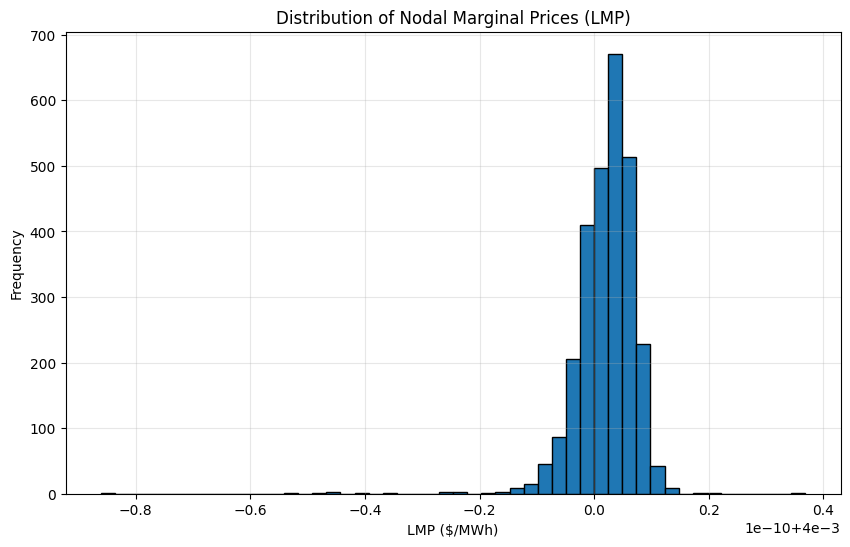

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(lmps, bins=50, edgecolor='black')
plt.xlabel('LMP ($/MWh)')
plt.ylabel('Frequency')
plt.title('Distribution of Nodal Marginal Prices (LMP)')
plt.grid(True, alpha=0.3)
plt.show()

In [27]:
lmps.min()

np.float64(0.0039999999139437295)

In [70]:
import pandapower as pp
import math

net = pp.create_empty_network()

bus_gen1 = pp.create_bus(net, vn_kv=110, name="Bus 1")
bus_top = pp.create_bus(net, vn_kv=110, name="Bus 2")
bus_gen2 = pp.create_bus(net, vn_kv=110, name="Bus 3")
bus_bottom = pp.create_bus(net, vn_kv=110, name="Bus 4")
bus_load1 = pp.create_bus(net, vn_kv=110, name="Bus 5")
bus_load2 = pp.create_bus(net, vn_kv=110, name="Bus 6")

gen1 = pp.create_gen(net, bus=bus_gen1, p_mw=100, min_p_mw=0, max_p_mw=500, min_q_mvar=-500, max_q_mvar=500, name="Gen 1", slack=True)
pp.create_poly_cost(net, element=gen1, et="gen", cp1_eur_per_mw=10, cp0_eur=0)
gen2 = pp.create_gen(net, bus=bus_gen2, p_mw=100, min_p_mw=0, max_p_mw=500, min_q_mvar=-500, max_q_mvar=500, name="Gen 2",)
pp.create_poly_cost(net, element=gen2, et="gen", cp1_eur_per_mw=0, cp0_eur=0)

load1 = pp.create_load(net, bus=bus_load1, p_mw=100, controllable=False, name="Load 1")
load2 = pp.create_load(net, bus=bus_load2, p_mw=120, controllable=False, name="Load 2")

line1 = pp.create_line(net, from_bus=bus_gen1, to_bus=bus_top, length_km=10, std_type="149-AL1/24-ST1A 110.0", max_loading_percent=101)
line2 = pp.create_line(net, from_bus=bus_top, to_bus=bus_load1, length_km=10, std_type="149-AL1/24-ST1A 110.0", max_loading_percent=101)
line3 = pp.create_line(net, from_bus=bus_top, to_bus=bus_load2, length_km=10, std_type="149-AL1/24-ST1A 110.0", max_loading_percent=101)
line4 = pp.create_line(net, from_bus=bus_bottom, to_bus=bus_load1, length_km=10, std_type="149-AL1/24-ST1A 110.0", max_loading_percent=101)
line5 = pp.create_line(net, from_bus=bus_bottom, to_bus=bus_load2, length_km=10, std_type="149-AL1/24-ST1A 110.0", max_loading_percent=101)
line6 = pp.create_line(net, from_bus=bus_gen2, to_bus=bus_bottom, length_km=10, std_type="149-AL1/24-ST1A 110.0", max_loading_percent=101)

net.line.loc[line1, 'max_i_ka'] = 500 / (math.sqrt(3) * 110)
net.line.loc[line2, 'max_i_ka'] = 500 / (math.sqrt(3) * 110)
net.line.loc[line3, 'max_i_ka'] = 500 / (math.sqrt(3) * 110)
net.line.loc[line4, 'max_i_ka'] = 50 / (math.sqrt(3) * 110)
net.line.loc[line5, 'max_i_ka'] = 50 / (math.sqrt(3) * 110)
net.line.loc[line6, 'max_i_ka'] = 500 / (math.sqrt(3) * 110)


pp.rundcopp(net)


In [71]:
net.res_bus

,vm_pu,va_degree,p_mw,q_mvar,lam_p,lam_q
0,1.0,0.000000,-129.000001,NaN,1.000000e+01,0.0
1,1.0,-2.504441,0.000000,NaN,1.000000e+01,0.0
2,1.0,-1.106614,-90.999999,NaN,-4.381686e-08,0.0
3,1.0,-2.873312,0.000000,NaN,-4.003415e-08,0.0
4,1.0,-3.659590,100.000000,NaN,5.000000e+00,0.0
5,1.0,-3.853733,120.000000,NaN,1.500000e+01,0.0


In [72]:
net.res_line

,p_from_mw,q_from_mvar,p_to_mw,q_to_mvar,pl_mw,ql_mvar,i_from_ka,i_to_ka,i_ka,vm_from_pu,va_from_degree,vm_to_pu,va_to_degree,loading_percent
0,129.000001,0.0,-129.000001,0.0,0.0,0.0,0.677074,0.677074,0.677074,1.0,0.000000,1.0,-2.504441,25.800000
1,59.500000,0.0,-59.500000,0.0,0.0,0.0,0.312294,0.312294,0.312294,1.0,-2.504441,1.0,-3.659590,11.900000
2,69.500000,0.0,-69.500000,0.0,0.0,0.0,0.364780,0.364780,0.364780,1.0,-2.504441,1.0,-3.853733,13.900000
3,40.500000,0.0,-40.500000,0.0,0.0,0.0,0.212570,0.212570,0.212570,1.0,-2.873312,1.0,-3.659590,80.999999
4,50.500000,0.0,-50.500000,0.0,0.0,0.0,0.265056,0.265056,0.265056,1.0,-2.873312,1.0,-3.853733,100.999999
5,90.999999,0.0,-90.999999,0.0,0.0,0.0,0.477626,0.477626,0.477626,1.0,-1.106614,1.0,-2.873312,18.200000


In [73]:
net.res_gen

,p_mw,q_mvar,va_degree,vm_pu
0,129.000001,NaN,0.000000,1.0
1,90.999999,NaN,-1.106614,1.0


In [74]:
net.res_cost

np.float64(1290.0000051283596)

In [ ]:
import pandapower as pp
import math

In [ ]:
def get_lmp(wind_load):
    # ==========================================
    # 1. 初始化电网
    # ==========================================
    net = pp.create_empty_network()

    # 创建两个区域的母线 (假设电压等级为 110 kV)
    bus_wind = pp.create_bus(net, vn_kv=110, name="Wind Region Bus", min_vm_pu=0.9, max_vm_pu=1.1)
    bus_therm = pp.create_bus(net, vn_kv=110, name="Thermal Region Bus", min_vm_pu=0.9, max_vm_pu=1.1)

    # ==========================================
    # 2. 部署发电机与成本设置
    # ==========================================
    # 区域 A: 风力发电场 (便宜，零碳排，最高出力可达 150 MW)
    # 设置 controllable=True 表示在 OPF 中允许弃风 (限制出力)
    wind_gen = pp.create_sgen(net, bus_wind, p_mw=40, min_p_mw=0, max_p_mw=75, 
                min_q_mvar=-30, max_q_mvar=30,
                controllable=True, name="Wind Farm")
    # 设定风电边际成本为 0 $/MWh
    pp.create_poly_cost(net, element=wind_gen, et="sgen", cp1_eur_per_mw=0.01, cp0_eur=0)

    backup_gen = pp.create_sgen(net, bus=bus_wind, p_mw=0, 
                            min_p_mw=0, max_p_mw=100, 
                            min_q_mvar=-30, max_q_mvar=30,
                            controllable=True, name="Local_Backup_Gen")
    pp.create_poly_cost(net, element=backup_gen, et="sgen", cp1_eur_per_mw=50, cp0_eur=0)

    # 区域 B: 火力发电厂 (我们用 ext_grid 模拟一个巨大的、昂贵的火力主网)
    thermal_gen = pp.create_ext_grid(net, bus_therm, min_p_mw=-500, max_p_mw=500, min_q_mvar=-500, max_q_mvar=500, name="Thermal Plant")
    # 设定火电边际成本为 20 $/MWh (较贵，有碳排)
    pp.create_poly_cost(net, element=thermal_gen, et="ext_grid", cp1_eur_per_mw=20, cp0_eur=0)
    
    # ==========================================
    # 3. 部署数据中心 (初始负载为总共 100 MW)
    # ==========================================
    total_load = 100
    
    # 风电节点旁边的数据中心
    pp.create_load(net, bus_wind, p_mw=wind_load, controllable=False, name="Datacenter_Wind")

    # 火电节点旁边的数据中心
    pp.create_load(net, bus_therm, p_mw=total_load - wind_load, controllable=False, name="Datacenter_Thermal")

    # ==========================================
    # 4. 建立“窄连接”以模拟输电瓶颈
    # ==========================================
    # 我们自定义一条 50km 的线路。
    # 关键参数: max_i_ka = 20 / (math.sqrt(3) * 110)。
    # 在 110kV 下，它的最大传输功率大约是 S = sqrt(3) * 110kV * x kA ≈ 20 MW。
    pp.create_line_from_parameters(net, from_bus=bus_wind, to_bus=bus_therm, length_km=50, 
                                r_ohm_per_km=0.1, x_ohm_per_km=0.3, c_nf_per_km=10, 
                                max_i_ka=20 / (math.sqrt(3) * 110), max_loading_percent=100, name="Narrow Transmission Line")
    
    try:
        pp.runopp(net)
        
        result = {}
        for idx, bus_name in enumerate(net.bus.name):
            lmp_col = [col for col in net.res_bus.columns if 'marginal_price' in col or col == 'lam_p'][0]
            result[bus_name] = float(net.res_bus.at[idx, lmp_col])
    except Exception as e:
        print(f"OPF 求解失败: {e}")
        result = None
    
    return result

In [81]:
wind_region_lmps = []
thermal_region_lmps = []
for load in range(0, 101):
    lmp_result = get_lmp(load)
    if lmp_result:
        wind_region_lmps.append(lmp_result["Wind Region Bus"])
        thermal_region_lmps.append(lmp_result["Thermal Region Bus"])

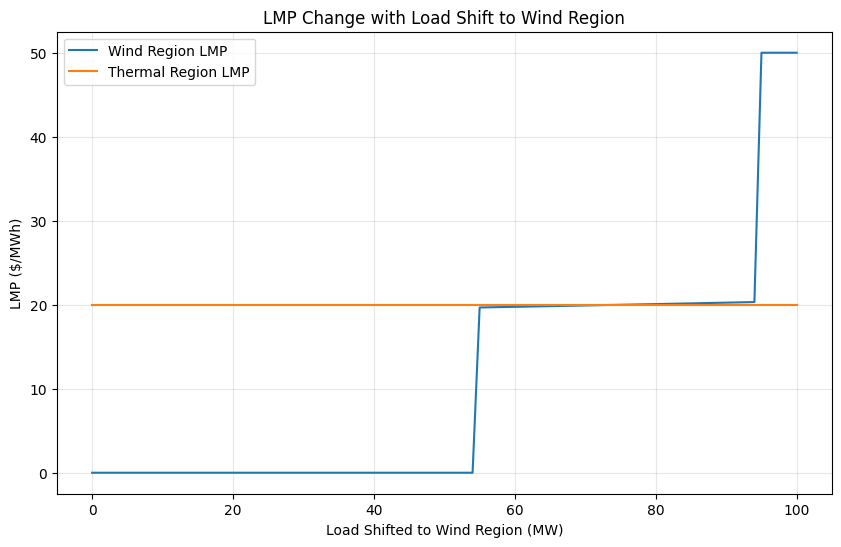

In [82]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.plot(range(0, 101), wind_region_lmps, label='Wind Region LMP')
plt.plot(range(0, 101), thermal_region_lmps, label='Thermal Region LMP')
plt.xlabel('Load Shifted to Wind Region (MW)')
plt.ylabel('LMP ($/MWh)')
plt.title('LMP Change with Load Shift to Wind Region')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [71]:
import pandapower as pp
import math

# ==========================================
# 1. 初始化电网
# ==========================================
net = pp.create_empty_network()

# 创建两个区域的母线 (假设电压等级为 110 kV)
bus_wind = pp.create_bus(net, vn_kv=110, name="Wind Region Bus", min_vm_pu=0.9, max_vm_pu=1.1)
bus_therm = pp.create_bus(net, vn_kv=110, name="Thermal Region Bus", min_vm_pu=0.9, max_vm_pu=1.1)

# ==========================================
# 2. 部署发电机与成本设置
# ==========================================
# 区域 A: 风力发电场 (便宜，零碳排，最高出力可达 150 MW)
# 设置 controllable=True 表示在 OPF 中允许弃风 (限制出力)
wind_gen = pp.create_sgen(net, bus_wind, p_mw=40, min_p_mw=0, max_p_mw=75, 
               min_q_mvar=-30, max_q_mvar=30,
               controllable=True, name="Wind Farm")
# 设定风电边际成本为 0 $/MWh
pp.create_poly_cost(net, element=wind_gen, et="sgen", cp1_eur_per_mw=0.01, cp0_eur=0)

backup_gen = pp.create_sgen(net, bus=bus_wind, p_mw=0, 
                           min_p_mw=0, max_p_mw=100, 
                           min_q_mvar=-30, max_q_mvar=30,
                           controllable=True, name="Local_Backup_Gen")
pp.create_poly_cost(net, element=backup_gen, et="sgen", cp1_eur_per_mw=50, cp0_eur=0)

# 区域 B: 火力发电厂 (我们用 ext_grid 模拟一个巨大的、昂贵的火力主网)
thermal_gen = pp.create_ext_grid(net, bus_therm, min_p_mw=-500, max_p_mw=500, min_q_mvar=-500, max_q_mvar=500, name="Thermal Plant")
# 设定火电边际成本为 20 $/MWh (较贵，有碳排)
pp.create_poly_cost(net, element=thermal_gen, et="ext_grid", cp1_eur_per_mw=20, cp0_eur=0)

# ==========================================
# 3. 部署数据中心 (初始负载为总共 100 MW)
# ==========================================
total_load = 100
wind_load = 55

# 风电节点旁边的数据中心
pp.create_load(net, bus_wind, p_mw=wind_load, controllable=False, name="Datacenter_Wind")

# 火电节点旁边的数据中心
pp.create_load(net, bus_therm, p_mw=total_load - wind_load, controllable=False, name="Datacenter_Thermal")

# ==========================================
# 4. 建立“窄连接”以模拟输电瓶颈
# ==========================================
# 我们自定义一条 50km 的线路。
# 关键参数: max_i_ka = 0.1 (最大电流限制为 0.1 千安)。
# 在 110kV 下，它的最大传输功率大约是 S = 1.732 * 110kV * 0.1kA ≈ 19 MW。
pp.create_line_from_parameters(net, from_bus=bus_wind, to_bus=bus_therm, length_km=50, 
                               r_ohm_per_km=0.1, x_ohm_per_km=0.3, c_nf_per_km=10, 
                               max_i_ka=20 / (math.sqrt(3) * 110), max_loading_percent=100, name="Narrow Transmission Line")

# ==========================================
# 5. 运行最优潮流 (OPF) 并分析结果
# ==========================================
try:
    pp.runopp(net)
    # pp.rundcpp(net)
    
    print("==== 节点边际电价 (LMP) ====")
    for idx, bus_name in enumerate(net.bus.name):
        # 兼容不同版本的 lmp 字段名
        lmp_col = [col for col in net.res_bus.columns if 'marginal_price' in col or col == 'lam_p'][0]
        print(f"{bus_name} LMP: {net.res_bus[lmp_col].at[idx]:.2f} $/MWh")
        
    print("\n==== 发电与弃风情况 ====")
    wind_generated = net.res_sgen.p_mw.at[0]
    print(f"风电场实际发电: {wind_generated:.2f} MW")
    
    backup_generated = net.res_sgen.p_mw.at[1]
    print(f"备用火电实际发电: {backup_generated:.2f} MW")
    
    thermal_generated = net.res_ext_grid.p_mw.at[0]
    print(f"火电厂实际发电: {thermal_generated:.2f} MW")

    print("\n==== 输电线负载率 ====")
    print(f"窄连接线路负载率: {net.res_line.loading_percent.at[0]:.2f} %")

except Exception as e:
    print(f"OPF 计算失败: {e}")

==== 节点边际电价 (LMP) ====
Wind Region Bus LMP: 19.68 $/MWh
Thermal Region Bus LMP: 20.00 $/MWh

==== 发电与弃风情况 ====
风电场实际发电: 75.00 MW
备用火电实际发电: 0.00 MW
火电厂实际发电: 25.16 MW

==== 输电线负载率 ====
窄连接线路负载率: 99.30 %


In [1]:
import andes
# 引入与 pandapower 的兼容接口
from andes.interop.pandapower import to_pandapower

# 指定你的文件路径
raw_file_path = "case_datasets/WECC_240_bus/240busWECC_2018_PSS.raw"

# 使用 ANDES 读取 .raw 文件并初始化系统
system = andes.load(raw_file_path, setup=False, no_output=True, default_config=True)
system.setup()

# 将 ANDES 系统一键转换为 pandapower 的 net 对象
net = to_pandapower(system)

print(net)

  6 slack generators are enabled on 1 bus(es): [3933].
/mnt/miniconda3/envs/migration/lib/python3.12/site-packages/andes/interop/pandapower.py:231: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bus_df['type'] = 'b'
/mnt/miniconda3/envs/migration/lib/python3.12/site-packages/andes/interop/pandapower.py:232: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bus_df['in_service'] = bus_df['in_service'].astype('bool')
/mnt/miniconda3/envs/migration/lib/python3.12/site-packages/andes/interop/pandapower.py:256: Settin

This pandapower network includes the following parameter tables:
   - bus (243 elements)
   - load (139 elements)
   - gen (146 elements)
   - shunt (7 elements)
   - line (329 elements)
   - trafo (122 elements)
 and the following results tables:
   - res_bus (243 elements)
   - res_line (329 elements)
   - res_trafo (122 elements)
   - res_load (139 elements)
   - res_shunt (7 elements)
   - res_gen (146 elements)


In [2]:
net.gen

,name,slack,bus,p_mw,vm_pu,controllable,in_service,max_p_mw,min_p_mw,max_q_mvar,min_q_mvar,slack_weight,scaling,sn_mva
0,1,False,4,712.000,1.014,True,True,873.0,0.0,200.0,-200.0,0.0,1,100.0
1,2,False,4,856.000,1.014,True,True,1050.0,0.0,357.0,-357.0,0.0,1,100.0
2,3,False,4,520.000,1.014,True,True,638.0,0.0,360.0,-360.0,0.0,1,100.0
3,4,False,5,1847.000,1.030,True,True,1944.0,0.0,500.0,-500.0,0.0,1,100.0
4,5,False,5,2565.000,1.030,True,True,2700.0,0.0,918.0,-918.0,0.0,1,100.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
141,75,True,157,0.000,1.020,True,False,0.0,-449.0,0.5,0.0,1.0,1,100.0
142,76,True,157,901.970,1.020,True,True,1927.0,0.0,500.0,-307.0,1.0,1,100.0
143,77,True,157,1275.022,1.020,True,True,2724.0,0.0,1256.0,-1041.0,1.0,1,100.0
144,78,True,157,346.372,1.020,True,True,740.0,0.0,200.0,-200.0,1.0,1,100.0


In [3]:
net.load

,name,in_service,p_mw,q_mvar,bus,sn_mva,controllable,type,const_i_p_percent,const_i_q_percent,const_z_p_percent,const_z_q_percent,scaling
0,PQ_1,True,226.841940,-599.999663,1,100.0,False,None,0,0,0,0,1
1,PQ_2,True,2153.320352,366.854960,2,100.0,False,None,0,0,0,0,1
2,PQ_3,True,1037.949540,5.520924,3,100.0,False,None,0,0,0,0,1
3,PQ_4,True,4527.366410,-137.044314,6,100.0,False,None,0,0,0,0,1
4,PQ_5,True,178.910679,23.651879,7,100.0,False,None,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
134,PQ_135,True,7000.917900,772.350304,232,100.0,False,None,0,0,0,0,1
135,PQ_136,True,2554.834170,-138.068694,233,100.0,False,None,0,0,0,0,1
136,PQ_137,True,587.404725,76.626027,238,100.0,False,None,0,0,0,0,1
137,PQ_138,True,3409.103000,444.699000,239,100.0,False,None,0,0,0,0,1


In [8]:
fuel_mapping = {}
record_buffer = ""  # 用于拼接跨行数据的缓冲区

with open('case_datasets/WECC_240_bus/240busWECC_2018_PSS.dyr', 'r') as f:
    for line in f:
        # 1. 跳过文件的注释行和纯空行
        if line.startswith('//') or not line.strip():
            continue
        
        # 2. 将当前行的内容拼接到缓冲区，用空格隔开
        record_buffer += " " + line.strip()
        
        # 3. 核心逻辑：只有当这行包含 '/' 时，才说明一条发电机记录彻底结束了
        if '/' in line:
            # 现在 record_buffer 里包含了这台设备完整的所有参数，再进行切分
            parts = record_buffer.split()
            
            if len(parts) >= 3:
                bus_id_str = parts[0]
                model_name = parts[1].strip("'")
                machine_id = parts[2]
                
                # 增加一层校验：确保切出来的第一个值确实是纯数字组成的 bus 编号
                if bus_id_str.isdigit():
                    bus_id = int(bus_id_str)
                    
                    # 匹配长度 <= 2 的字符编号 (比如 C, G, TG, EG)
                    if len(machine_id) <= 2 and machine_id.isalnum():
                        # 只筛选真正的发电机本体模型
                        if model_name.startswith('GEN'):
                            fuel_mapping[(bus_id, machine_id)] = machine_id
            
            # 4. 解析完毕后，立刻清空缓冲区，准备迎接下一台设备的跨行数据
            record_buffer = ""

# 打印前 15 个映射关系，看看成果
for key, fuel in list(fuel_mapping.items()):
    print(f"Bus {key[0]}, Gen ID {key[1]} -> Label: {fuel}")

Bus 1032, Gen ID C -> Label: C
Bus 1032, Gen ID G -> Label: G
Bus 1034, Gen ID C -> Label: C
Bus 1034, Gen ID G -> Label: G
Bus 1131, Gen ID C -> Label: C
Bus 1131, Gen ID G -> Label: G
Bus 1232, Gen ID C -> Label: C
Bus 1232, Gen ID H -> Label: H
Bus 1331, Gen ID G -> Label: G
Bus 1331, Gen ID H -> Label: H
Bus 1333, Gen ID C -> Label: C
Bus 1333, Gen ID G -> Label: G
Bus 1431, Gen ID G -> Label: G
Bus 1431, Gen ID N -> Label: N
Bus 2030, Gen ID E -> Label: E
Bus 2030, Gen ID G -> Label: G
Bus 2130, Gen ID E -> Label: E
Bus 2130, Gen ID G -> Label: G
Bus 2130, Gen ID H -> Label: H
Bus 2233, Gen ID DG -> Label: DG
Bus 2233, Gen ID EG -> Label: EG
Bus 2233, Gen ID TG -> Label: TG
Bus 2438, Gen ID EG -> Label: EG
Bus 2438, Gen ID ND -> Label: ND
Bus 2438, Gen ID RG -> Label: RG
Bus 2438, Gen ID SG -> Label: SG
Bus 2438, Gen ID SH -> Label: SH
Bus 2438, Gen ID WG -> Label: WG
Bus 2630, Gen ID G -> Label: G
Bus 2634, Gen ID C -> Label: C
Bus 2637, Gen ID H -> Label: H
Bus 2638, Gen ID H ->